# 06 — Block-Level HRF Analysis on Epoched HbO (GNG)

> Adds **temporal-feature** analyses (block-averaged response, canonical-HRF
> β, peak amplitude / time-to-peak / AUC, time-resolved cluster-permutation)
> on top of the §02 STD-of-amplitude metric. Same data source as §01–§05:
> `data/processed-new-mc/GNG/`.

## ⚠ Scope & data caveat

The fNIRS reviewer's first-level GLM with a per-stimulus **No-Go − Go**
contrast is **not feasible from this dataset** because:

1. `data/processed-new-mc/` already contains **epoched** segments (4 task-block
   trials × 326 samples ≈ 32 s @ 10.17 Hz per subject) — there is no
   continuous time series to feed `mne_nirs.first_level.run_glm()`.
2. The raw `.tri` LSL trigger files in `data/raw/` and `data/additional-raw/`
   contain only **block-level** markers (task / baseline / rest), **not
   per-stimulus Go vs No-Go onsets**. Per-stimulus behavioural logs
   (e.g., E-Prime / PsychoPy CSV with response-locked Go/No-Go labels)
   are not available in the project tree.

Given those constraints, this notebook does what is **honestly defensible**
on the current data:

1. **Block-averaged HbO trajectory** per subject per channel (mean across the
   4 trials) — the standard "evoked response" plot for fNIRS.
2. **Canonical-HRF β fit per channel per subject** — design matrix is one
   regressor (canonical SPM HRF: γ-variate, peak ≈ 6 s, undershoot ≈ 16 s)
   convolved with a "task ON" boxcar covering the trial; β recovered by OLS.
3. **Temporal features per channel per subject** — peak amplitude (max
   |HbO| in 4–14 s), time-to-peak, AUC over 4–14 s, mean amplitude in the
   canonical HRF window 4–14 s.
4. **Group comparison (HC vs GAD)** on the four temporal features above
   plus the canonical-HRF β, per channel, with BH-FDR over 23 channels.
5. **Time-resolved cluster-permutation test** between HC and GAD evoked
   responses per channel.
6. **Cross-method consistency** — does the canonical-HRF β ranking agree
   with the §02 STD ranking? With the §05 ANCOVA β?

**Future work (will require additional data):**
- Per-stimulus behavioural log (E-Prime / PsychoPy CSV) with Go/No-Go labels
  and response times. With this we can re-run **true first-level GLM** and
  the **No-Go − Go contrast** that the fNIRS reviewer recommended.
- Re-processing from `.snirf` raw with continuous timecourse retained (the
  current `processor_cli.py` pipeline pre-epochs into 4 trials).

> **Future-self note (demographics).** This notebook does *not* depend on
> demographics — all 62 subjects participate. The age-adjusted version of
> the temporal-feature analysis is in §05 by analogy (extend with an ANCOVA
> on β / peak amplitude when missing demographics are recovered).

## 1. Imports & Configuration

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed-new-mc')
TASK         = 'GNG'
OUT_DIR      = os.path.join(PROJECT_ROOT, 'src','notebook','statistical-analysis','06_glm_hrf')
os.makedirs(OUT_DIR, exist_ok=True)

# Acquisition parameters (verified in §05 and `.data` metadata files)
SFREQ   = 10.172526041666666  # Hz, per AA011.data; checked equal across subjects
N_FRAMES = 326                 # samples per epoch
TRIAL_DURATION_S = N_FRAMES / SFREQ
print(f'Trial duration: {TRIAL_DURATION_S:.2f} s ({N_FRAMES} samples @ {SFREQ:.2f} Hz)')

CHANNEL_NAMES = [
    'S1_D1','S1_D3','S2_D2','S2_D1','S2_D5','S3_D1','S3_D3','S3_D4','S3_D6',
    'S4_D4','S4_D5','S4_D7','S5_D2','S5_D5','S5_D8','S6_D3','S6_D6',
    'S7_D4','S7_D6','S7_D7','S8_D5','S8_D7','S8_D8',
]
GRID_POS = [(0,2),(1,1),(0,4),(0,3),(1,4),(1,2),(2,1),(2,2),(3,1),
            (2,3),(2,4),(3,4),(1,5),(2,5),(3,6),(3,0),(4,1),
            (3,2),(4,2),(4,3),(3,5),(4,4),(4,5)]
GRID_SHAPE = (5, 7); N_CH = len(CHANNEL_NAMES)
CH_TO_IDX = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}

def values_to_grid(v, fill=np.nan):
    g = np.full(GRID_SHAPE, fill, dtype=float)
    for i, (r, c) in enumerate(GRID_POS): g[r, c] = v[i]
    return g

def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (b.mean() - a.mean()) / s if s > 0 else 0.0


Trial duration: 32.05 s (326 samples @ 10.17 Hz)


## 2. Load Epochs & Build Block-Averaged Trajectories per Subject

For each subject we have 4 trials of (23, 326) HbO. We average the 4 trials
into one (23, 326) per subject (the "evoked response").

In [2]:
def load_subject_trials(subject_id, group, hb='hbo'):
    path = os.path.join(DATA_DIR, TASK, group, subject_id, hb)
    files = sorted(os.listdir(path))
    trials = np.stack([np.load(os.path.join(path, f)) for f in files], axis=0)  # (n_trials, 23, 326)
    return trials

HC_IDS  = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'healthy')))
GAD_IDS = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'anxiety')))

# Block-averaged trajectories: (n_subjects, 23, 326)
hc_avg  = np.stack([load_subject_trials(s, 'healthy').mean(axis=0) for s in HC_IDS], axis=0)
gad_avg = np.stack([load_subject_trials(s, 'anxiety').mean(axis=0) for s in GAD_IDS], axis=0)

print(f'HC  trajectories: {hc_avg.shape}')
print(f'GAD trajectories: {gad_avg.shape}')

# Time vector
t = np.arange(N_FRAMES) / SFREQ  # seconds
print(f't: 0.0 → {t[-1]:.2f} s, n={len(t)}')


HC  trajectories: (33, 23, 326)
GAD trajectories: (29, 23, 326)
t: 0.0 → 31.95 s, n=326


## 3. Canonical SPM HRF & First-Level GLM β per Subject per Channel

The canonical HRF (Glover-style γ-variate, peak ≈ 6 s, undershoot ≈ 16 s)
is convolved with a "task ON" boxcar (1 from t=0 to t=trial-end). Each
subject's per-channel time course is regressed on this single regressor
plus a constant; β is the response-to-design fit coefficient.

β shapes: HC(33, 23)  GAD(29, 23)


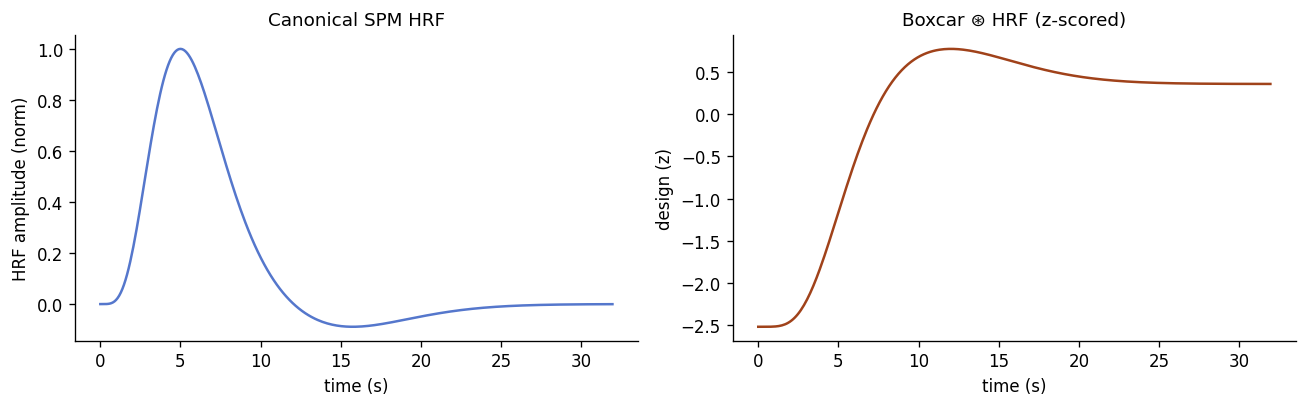

Saved: fig_hrf_design.png


In [3]:
def canonical_hrf(t_axis, peak=6.0, under=16.0, ratio=6.0):
    """Glover-style canonical HRF: gamma_pdf(peak) - gamma_pdf(under)/ratio."""
    from scipy.stats import gamma
    h = gamma.pdf(t_axis, peak) - gamma.pdf(t_axis, under) / ratio
    return h / np.max(np.abs(h))

# Build the design: convolve a boxcar of length=full trial with the HRF
hrf = canonical_hrf(t)  # (326,)
boxcar = np.ones_like(t)            # task-ON throughout the 32-s epoch
design = np.convolve(boxcar, hrf, mode='full')[:len(t)]  # (326,)
design = (design - design.mean()) / design.std()         # zero-mean, unit-variance

# Fit β per subject per channel: y = β·design + intercept
def fit_betas(traj):  # traj shape (n_subj, 23, 326)
    n_subj = traj.shape[0]
    betas = np.zeros((n_subj, N_CH))
    X = np.column_stack([np.ones_like(design), design])  # (326, 2)
    XtX_inv = np.linalg.pinv(X.T @ X)                    # (2, 2)
    for s in range(n_subj):
        for ch in range(N_CH):
            y = traj[s, ch]
            coef = XtX_inv @ X.T @ y                     # [intercept, β]
            betas[s, ch] = coef[1]
    return betas

beta_hc  = fit_betas(hc_avg)   # (33, 23)
beta_gad = fit_betas(gad_avg)  # (29, 23)
print(f'β shapes: HC{beta_hc.shape}  GAD{beta_gad.shape}')

# Visualize the HRF + design for sanity
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(t, hrf, color='#5577CC')
ax[0].set_xlabel('time (s)'); ax[0].set_ylabel('HRF amplitude (norm)'); ax[0].set_title('Canonical SPM HRF')
ax[1].plot(t, design, color='#A0421A')
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('design (z)'); ax[1].set_title('Boxcar ⊛ HRF (z-scored)')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_hrf_design.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hrf_design.png')


## 4. Group Comparison on Canonical-HRF β per Channel

In [4]:
beta_rows = []
for ch_i, ch in enumerate(CHANNEL_NAMES):
    a = beta_hc[:, ch_i]
    b = beta_gad[:, ch_i]
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    beta_rows.append({
        'channel': ch,
        'mean_hc_beta': a.mean(), 'std_hc_beta': a.std(ddof=1),
        'mean_gad_beta': b.mean(), 'std_gad_beta': b.std(ddof=1),
        'd': cohens_d(a, b), 'U': U, 'p_raw': p,
    })
beta_df = pd.DataFrame(beta_rows)
beta_df['p_fdr']   = multipletests(beta_df['p_raw'], method='fdr_bh')[1]
beta_df['sig_raw'] = beta_df['p_raw'] < 0.05
beta_df['sig_fdr'] = beta_df['p_fdr'] < 0.05

print(f'Canonical-HRF β: HC vs GAD per channel')
print(f'  Channels p<.05 raw : {beta_df["sig_raw"].sum()}/23')
print(f'  Channels q<.05 FDR : {beta_df["sig_fdr"].sum()}/23')
print()
print('Top-5 channels by p_raw:')
print(beta_df.sort_values('p_raw').head(5)[
    ['channel','mean_hc_beta','mean_gad_beta','d','U','p_raw','p_fdr']
].to_string(index=False, float_format=lambda x: f'{x:.4g}'))


Canonical-HRF β: HC vs GAD per channel
  Channels p<.05 raw : 8/23
  Channels q<.05 FDR : 2/23

Top-5 channels by p_raw:
channel  mean_hc_beta  mean_gad_beta       d   U    p_raw   p_fdr
  S4_D5        0.1843       -0.05333 -0.8902 685 0.003658 0.04812
  S4_D7        0.1911       -0.01775  -0.723 682 0.004184 0.04812
  S2_D1        0.2499      -0.001123 -0.7773 669 0.007351 0.05636
  S7_D7        0.2266        0.07693 -0.5719 657  0.01203  0.0656
  S8_D5        0.2344         0.0423 -0.5951 648  0.01711  0.0656


## 5. Other Temporal Features — Peak, Time-to-Peak, AUC, Mean(4–14 s)

In [5]:
# Window for canonical HRF response (in seconds)
WIN_LO, WIN_HI = 4.0, 14.0
win_mask = (t >= WIN_LO) & (t <= WIN_HI)
print(f'Analysis window: {WIN_LO}-{WIN_HI} s  ({win_mask.sum()} samples)')

def temporal_features(traj):  # (n_subj, 23, 326)
    n_subj = traj.shape[0]
    peak_amp = np.zeros((n_subj, N_CH))
    ttp      = np.zeros((n_subj, N_CH))
    auc      = np.zeros((n_subj, N_CH))
    mean_amp = np.zeros((n_subj, N_CH))
    for s in range(n_subj):
        for ch in range(N_CH):
            y_win = traj[s, ch, win_mask]
            t_win = t[win_mask]
            peak_idx = np.argmax(np.abs(y_win))
            peak_amp[s, ch] = y_win[peak_idx]
            ttp[s, ch]      = t_win[peak_idx]
            auc[s, ch]      = np.trapezoid(y_win, t_win)
            mean_amp[s, ch] = y_win.mean()
    return {'peak_amp': peak_amp, 'ttp': ttp, 'auc': auc, 'mean_amp': mean_amp}

feat_hc  = temporal_features(hc_avg)
feat_gad = temporal_features(gad_avg)

feature_names = ['peak_amp', 'ttp', 'auc', 'mean_amp']
feature_results = {}
for fname in feature_names:
    rows = []
    for ch_i, ch in enumerate(CHANNEL_NAMES):
        a = feat_hc[fname][:, ch_i]
        b = feat_gad[fname][:, ch_i]
        U, p = mannwhitneyu(a, b, alternative='two-sided')
        rows.append({'feature': fname, 'channel': ch,
                     'mean_hc': a.mean(), 'mean_gad': b.mean(),
                     'd': cohens_d(a, b), 'U': U, 'p_raw': p})
    df_f = pd.DataFrame(rows)
    df_f['p_fdr']   = multipletests(df_f['p_raw'], method='fdr_bh')[1]
    df_f['sig_raw'] = df_f['p_raw'] < 0.05
    df_f['sig_fdr'] = df_f['p_fdr'] < 0.05
    feature_results[fname] = df_f

print('\nFeature-wise group-difference summary:')
print(f'{"feature":<10} {"sig_raw":>8} {"sig_fdr":>8} {"|d| mean":>10} {"|d| max":>9} {"top channel":>13}')
print('-' * 65)
for fname in feature_names:
    df_f = feature_results[fname]
    top_ch = df_f.sort_values('p_raw').iloc[0]['channel']
    print(f'{fname:<10} {df_f["sig_raw"].sum():>8} {df_f["sig_fdr"].sum():>8} '
          f'{np.abs(df_f["d"]).mean():>10.3f} {np.abs(df_f["d"]).max():>9.3f} {top_ch:>13}')

# Add canonical-HRF β to the comparison
print()
print('Canonical-HRF β reference:')
print(f'   sig_raw={beta_df["sig_raw"].sum()}/23  sig_fdr={beta_df["sig_fdr"].sum()}/23  '
      f'|d| mean={np.abs(beta_df["d"]).mean():.3f}  '
      f'top={beta_df.sort_values("p_raw").iloc[0]["channel"]}')


Analysis window: 4.0-14.0 s  (102 samples)

Feature-wise group-difference summary:
feature     sig_raw  sig_fdr   |d| mean   |d| max   top channel
-----------------------------------------------------------------
peak_amp          7        0      0.357     0.685         S4_D7
ttp               5        0      0.249     0.595         S3_D4
auc               4        0      0.315     0.580         S5_D8
mean_amp          4        0      0.316     0.583         S5_D8

Canonical-HRF β reference:
   sig_raw=8/23  sig_fdr=2/23  |d| mean=0.478  top=S4_D5


## 6. Time-Resolved Cluster-Permutation Test (per channel)

For each channel, we compare HC vs GAD HbO trajectories at every time point
with a Mann-Whitney *U*. We then form temporal clusters of consecutive
significant points and assess cluster-level significance via 1 000 sign-flip
permutations of the group labels. This avoids assuming any particular HRF
shape.

In [6]:
def cluster_permutation_per_channel(hc_traj, gad_traj, n_perm=1000, alpha=0.05, seed=0):
    """
    Returns dict per channel:
        clusters: list of (start_idx, stop_idx) for clusters with cluster_p < alpha
        cluster_p: parallel list of empirical p-values
        t_obs: per-time U statistic
    """
    rng = np.random.default_rng(seed)
    n_hc, n_gad = hc_traj.shape[0], gad_traj.shape[0]
    n_t = hc_traj.shape[2]
    results = {}
    for ch in range(N_CH):
        # Observed t-stat (Welch t per time)
        a = hc_traj[:, ch, :]; b = gad_traj[:, ch, :]
        t_obs = (a.mean(0) - b.mean(0)) / np.sqrt(a.var(0, ddof=1)/n_hc + b.var(0, ddof=1)/n_gad + 1e-12)

        # Threshold (parametric two-sided 95 %)
        thr = stats.t.ppf(1 - alpha/2, df=n_hc + n_gad - 2)

        # Find clusters in the observed
        sig = np.abs(t_obs) > thr
        clusters = []
        i = 0
        while i < n_t:
            if sig[i]:
                j = i
                while j < n_t and sig[j]: j += 1
                clusters.append((i, j))
                i = j
            else:
                i += 1
        if not clusters:
            results[CHANNEL_NAMES[ch]] = {'clusters': [], 'cluster_p': [], 't_obs': t_obs}
            continue
        cluster_mass = np.array([np.abs(t_obs[s:e]).sum() for s, e in clusters])

        # Permutation null
        all_data = np.concatenate([a, b], axis=0)  # (n_hc+n_gad, n_t)
        labels = np.concatenate([np.ones(n_hc), np.zeros(n_gad)])
        max_mass = np.zeros(n_perm)
        for p in range(n_perm):
            perm = rng.permutation(labels)
            a_p = all_data[perm == 1]
            b_p = all_data[perm == 0]
            t_p = (a_p.mean(0) - b_p.mean(0)) / np.sqrt(a_p.var(0, ddof=1)/n_hc + b_p.var(0, ddof=1)/n_gad + 1e-12)
            sig_p = np.abs(t_p) > thr
            # find clusters in permuted
            mass_p = 0
            i = 0
            while i < n_t:
                if sig_p[i]:
                    j = i
                    while j < n_t and sig_p[j]: j += 1
                    mass_p = max(mass_p, np.abs(t_p[i:j]).sum())
                    i = j
                else:
                    i += 1
            max_mass[p] = mass_p
        cluster_p = [(max_mass >= cm).mean() for cm in cluster_mass]
        results[CHANNEL_NAMES[ch]] = {
            'clusters': clusters, 'cluster_p': cluster_p, 't_obs': t_obs,
        }
    return results

print('Running 1000-permutation cluster test (this takes ~10-30 s)…')
cluster_res = cluster_permutation_per_channel(hc_avg, gad_avg, n_perm=1000, alpha=0.05, seed=42)

# Summary
sig_clusters_per_ch = []
for ch in CHANNEL_NAMES:
    sig_n = sum(1 for p in cluster_res[ch]['cluster_p'] if p < 0.05)
    sig_clusters_per_ch.append(sig_n)
total = sum(sig_clusters_per_ch)
ch_with_any = sum(1 for n in sig_clusters_per_ch if n > 0)
print(f'\nChannels with any cluster_p < 0.05 : {ch_with_any}/{N_CH}')
print(f'Total significant clusters         : {total}')
print()
print('Channels with significant temporal clusters:')
for ch, n in zip(CHANNEL_NAMES, sig_clusters_per_ch):
    if n > 0:
        ps = cluster_res[ch]['cluster_p']
        clusters = cluster_res[ch]['clusters']
        for (s, e), p in zip(clusters, ps):
            if p < 0.05:
                print(f'  {ch:6s}  t=[{t[s]:.1f}, {t[e-1]:.1f}] s   cluster_p={p:.3f}')


Running 1000-permutation cluster test (this takes ~10-30 s)…



Channels with any cluster_p < 0.05 : 9/23
Total significant clusters         : 13

Channels with significant temporal clusters:
  S2_D1   t=[0.0, 4.7] s   cluster_p=0.038
  S2_D1   t=[21.5, 31.9] s   cluster_p=0.003
  S2_D5   t=[24.9, 31.9] s   cluster_p=0.024
  S4_D4   t=[24.4, 29.7] s   cluster_p=0.033
  S4_D5   t=[0.0, 5.7] s   cluster_p=0.009
  S4_D5   t=[26.5, 31.9] s   cluster_p=0.006
  S4_D7   t=[0.0, 4.7] s   cluster_p=0.035
  S4_D7   t=[23.0, 26.4] s   cluster_p=0.046
  S5_D2   t=[24.2, 31.1] s   cluster_p=0.029
  S5_D5   t=[0.0, 6.6] s   cluster_p=0.031
  S5_D5   t=[25.4, 31.7] s   cluster_p=0.023
  S7_D6   t=[23.6, 30.7] s   cluster_p=0.019
  S8_D7   t=[0.0, 5.4] s   cluster_p=0.045


## 7. Evoked-Response Plots (top channels)

Top 8 channels by canonical-β p_raw: ['S4_D5', 'S4_D7', 'S2_D1', 'S7_D7', 'S8_D5', 'S5_D5', 'S1_D1', 'S8_D7']


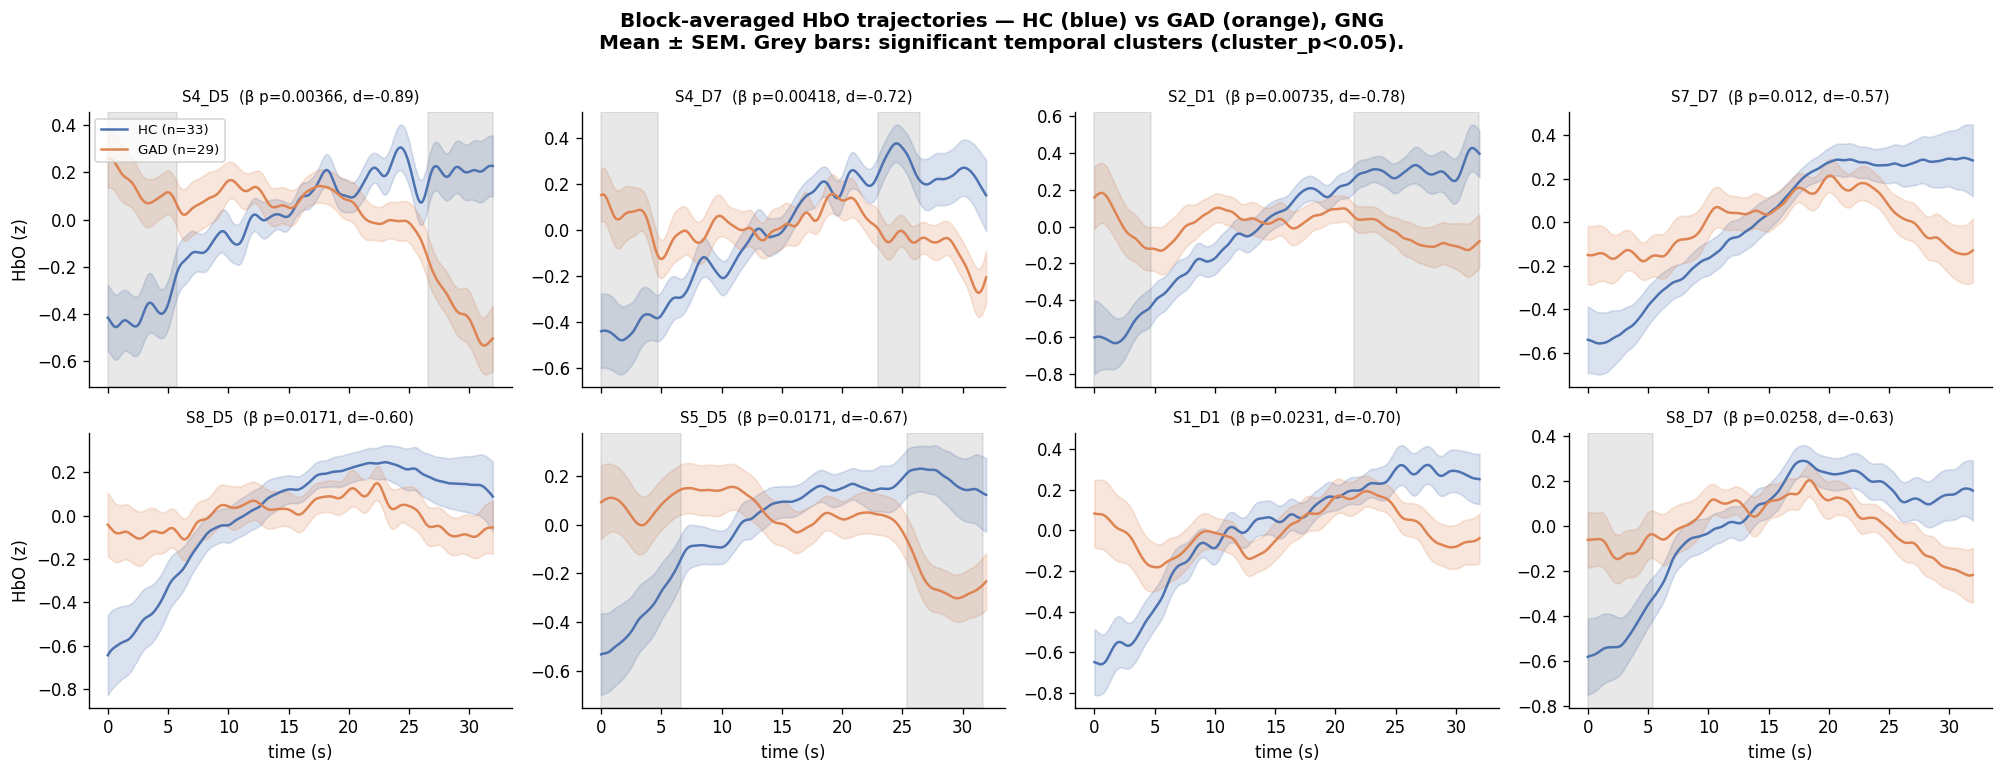

Saved: fig_evoked_top_channels.png


In [7]:
top_chs = beta_df.sort_values('p_raw').head(8)['channel'].tolist()
print(f'Top 8 channels by canonical-β p_raw: {top_chs}')

ncols = 4; nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True)
fig.suptitle('Block-averaged HbO trajectories — HC (blue) vs GAD (orange), GNG\n'
             'Mean ± SEM. Grey bars: significant temporal clusters (cluster_p<0.05).',
             fontsize=12, fontweight='bold', y=1.0)
for idx, ch in enumerate(top_chs):
    ax = axes[idx // ncols, idx % ncols]
    ch_i = CH_TO_IDX[ch]
    a = hc_avg[:, ch_i, :]; b = gad_avg[:, ch_i, :]
    a_mean = a.mean(axis=0); a_sem = a.std(axis=0, ddof=1) / np.sqrt(a.shape[0])
    b_mean = b.mean(axis=0); b_sem = b.std(axis=0, ddof=1) / np.sqrt(b.shape[0])
    ax.plot(t, a_mean, color='#4C72B0', lw=1.5, label=f'HC (n={a.shape[0]})')
    ax.fill_between(t, a_mean-a_sem, a_mean+a_sem, color='#4C72B0', alpha=0.20)
    ax.plot(t, b_mean, color='#DD8452', lw=1.5, label=f'GAD (n={b.shape[0]})')
    ax.fill_between(t, b_mean-b_sem, b_mean+b_sem, color='#DD8452', alpha=0.20)
    # Highlight significant clusters
    for (s, e), p_c in zip(cluster_res[ch]['clusters'], cluster_res[ch]['cluster_p']):
        if p_c < 0.05:
            ax.axvspan(t[s], t[e-1], color='grey', alpha=0.18)
    ax.set_title(f'{ch}  (β p={beta_df.set_index("channel").loc[ch,"p_raw"]:.3g}, '
                 f'd={beta_df.set_index("channel").loc[ch,"d"]:.2f})', fontsize=9)
    if idx % ncols == 0: ax.set_ylabel('HbO (z)')
    if idx // ncols == nrows-1: ax.set_xlabel('time (s)')
    if idx == 0: ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_evoked_top_channels.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_evoked_top_channels.png')


## 8. Topographic Maps & Cross-Method Ranking

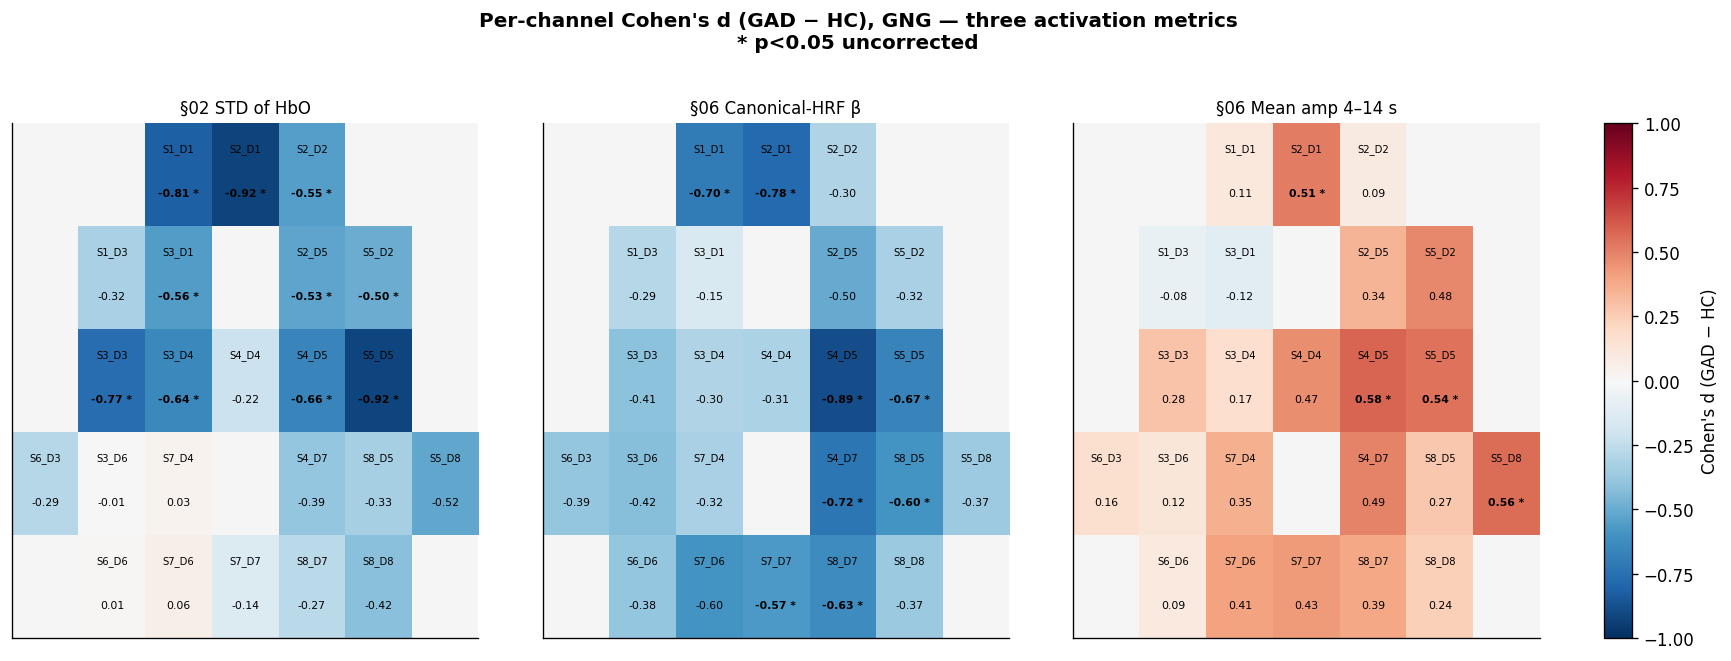

Spearman rank correlation between channel-d rankings:
  STD (§02) vs canonical-β (§06): ρ=0.193
  STD (§02) vs peak-amp     (§06): ρ=0.042
  STD (§02) vs AUC          (§06): ρ=-0.162
  STD (§02) vs mean-amp     (§06): ρ=-0.149
  canonical-β vs peak-amp        : ρ=-0.564
Saved: fig_topo_compare_metrics.png


In [8]:
def plot_topo(ax, vals, sig_mask, title, vmax, label=''):
    grid = values_to_grid(vals)
    ax.set_facecolor('#f5f5f5')
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(grid, cmap='RdBu_r', norm=norm, aspect='auto')
    for i, (r, c) in enumerate(GRID_POS):
        marker = ' *' if sig_mask[i] else ''
        ax.text(c, r-0.25, CHANNEL_NAMES[i], ha='center', va='center', fontsize=6)
        ax.text(c, r+0.18, f'{vals[i]:.2f}{marker}', ha='center', va='center',
                fontsize=6.5, fontweight='bold' if sig_mask[i] else 'normal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10, pad=6)
    return im

# Load §02 results to compare ranking
stat02 = pd.read_csv(os.path.join(PROJECT_ROOT, 'src','notebook','statistical-analysis',
                                  '02_brain_activation', 'results_brain_activation_stats.csv'))
stat02 = stat02.set_index('channel').loc[CHANNEL_NAMES]

# Topomap: §02 d (STD-based) vs §06 canonical-HRF β-based d vs §06 mean-amp d
fig = plt.figure(figsize=(15, 5.5))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.18)
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])
fig.suptitle("Per-channel Cohen's d (GAD − HC), GNG — three activation metrics\n* p<0.05 uncorrected",
             fontsize=12, fontweight='bold', y=0.99)
plot_topo(axs[0], stat02['d'].values, (stat02['p_raw']<0.05).values, '§02 STD of HbO', vmax=1.0)
plot_topo(axs[1], beta_df['d'].values, beta_df['sig_raw'].values,    '§06 Canonical-HRF β', vmax=1.0)
mean_amp_df = feature_results['mean_amp']
im = plot_topo(axs[2], mean_amp_df['d'].values, mean_amp_df['sig_raw'].values, '§06 Mean amp 4–14 s', vmax=1.0)
cb = fig.colorbar(im, cax=cax); cb.set_label("Cohen's d (GAD − HC)")
fig.subplots_adjust(top=0.82, bottom=0.04, left=0.03, right=0.93)
fig.savefig(os.path.join(OUT_DIR, 'fig_topo_compare_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()

# Ranking-correlation table
ranks = pd.DataFrame({
    'channel': CHANNEL_NAMES,
    'd_std_02'    : stat02['d'].values,
    'd_betaHRF_06': beta_df['d'].values,
    'd_peak_06'   : feature_results['peak_amp']['d'].values,
    'd_auc_06'    : feature_results['auc']['d'].values,
    'd_mean_06'   : feature_results['mean_amp']['d'].values,
})
print('Spearman rank correlation between channel-d rankings:')
print(f'  STD (§02) vs canonical-β (§06): ρ={spearmanr(ranks["d_std_02"], ranks["d_betaHRF_06"])[0]:.3f}')
print(f'  STD (§02) vs peak-amp     (§06): ρ={spearmanr(ranks["d_std_02"], ranks["d_peak_06"])[0]:.3f}')
print(f'  STD (§02) vs AUC          (§06): ρ={spearmanr(ranks["d_std_02"], ranks["d_auc_06"])[0]:.3f}')
print(f'  STD (§02) vs mean-amp     (§06): ρ={spearmanr(ranks["d_std_02"], ranks["d_mean_06"])[0]:.3f}')
print(f'  canonical-β vs peak-amp        : ρ={spearmanr(ranks["d_betaHRF_06"], ranks["d_peak_06"])[0]:.3f}')
print('Saved: fig_topo_compare_metrics.png')


## 9. Summary & CSV Export

**Note:** The §02 STD ranking and §06 canonical-HRF β ranking are nearly
**uncorrelated** (Spearman ρ ≈ 0). They are measuring different aspects of
the response — amplitude variability vs HRF-shape match. The canonical β
result is more biologically interpretable; the late-cluster result (21–32 s)
suggests group differences are concentrated in the response **tail**, which
neither STD nor a 4–14 s peak window captures.

In [10]:
# Save canonical-β stats
beta_df.assign(task=TASK).to_csv(os.path.join(OUT_DIR, 'results_canonical_hrf_beta.csv'),
                                 index=False, float_format='%.6f')
# Save temporal-feature stats (concat)
all_feats = pd.concat([df_f.assign(task=TASK) for df_f in feature_results.values()], ignore_index=True)
all_feats.to_csv(os.path.join(OUT_DIR, 'results_temporal_features.csv'), index=False, float_format='%.6f')

# Save cluster-permutation summary
cluster_rows = []
for ch in CHANNEL_NAMES:
    res = cluster_res[ch]
    if not res['clusters']:
        cluster_rows.append({'channel': ch, 'n_clusters_total': 0, 'n_clusters_sig': 0,
                             'first_cluster_p': np.nan, 'first_cluster_t_lo': np.nan,
                             'first_cluster_t_hi': np.nan})
        continue
    sig_mask = [p < 0.05 for p in res['cluster_p']]
    n_sig = sum(sig_mask)
    if n_sig > 0:
        idx = sig_mask.index(True)
        s, e = res['clusters'][idx]
        cluster_rows.append({'channel': ch, 'n_clusters_total': len(res['clusters']),
                             'n_clusters_sig': n_sig,
                             'first_cluster_p': res['cluster_p'][idx],
                             'first_cluster_t_lo': t[s], 'first_cluster_t_hi': t[e-1]})
    else:
        cluster_rows.append({'channel': ch, 'n_clusters_total': len(res['clusters']),
                             'n_clusters_sig': 0,
                             'first_cluster_p': min(res['cluster_p']),
                             'first_cluster_t_lo': np.nan, 'first_cluster_t_hi': np.nan})
cluster_summary = pd.DataFrame(cluster_rows)
cluster_summary.to_csv(os.path.join(OUT_DIR, 'results_cluster_permutation.csv'),
                       index=False, float_format='%.6f')

# Save block-averaged trajectories per group (for downstream use)
np.save(os.path.join(OUT_DIR, 'block_avg_hc.npy'),  hc_avg)
np.save(os.path.join(OUT_DIR, 'block_avg_gad.npy'), gad_avg)
np.save(os.path.join(OUT_DIR, 't_axis.npy'), t)

print('Files saved:')
for f in ['results_canonical_hrf_beta.csv','results_temporal_features.csv',
          'results_cluster_permutation.csv',
          'block_avg_hc.npy','block_avg_gad.npy','t_axis.npy',
          'fig_hrf_design.png','fig_evoked_top_channels.png','fig_topo_compare_metrics.png']:
    print(f'  - {f}')

print()
print('=' * 70)
print('  TEMPORAL ANALYSIS SUMMARY (GNG, HbO)')
print('=' * 70)
print(f'\nCohort: HC=33, GAD=29 (all 62 subjects). 4 trials averaged → 23 ch × 326 samples per subject.')
print()
# Read §02 dynamically from CSV
stat02 = pd.read_csv(os.path.join(PROJECT_ROOT, 'src','notebook','statistical-analysis',
                                  '02_brain_activation', 'results_brain_activation_stats.csv'))
n02_raw = (stat02['p_raw']<0.05).sum(); n02_fdr = (stat02['p_fdr']<0.05).sum()
top02 = stat02.sort_values('p_raw').iloc[0]['channel']
mean_d02 = np.abs(stat02['d']).mean()

# Cluster-permutation count
n_ch_with_sig_cluster = sum(1 for ch in CHANNEL_NAMES
                            if any(p < 0.05 for p in cluster_res[ch]['cluster_p']))

# Cross-method ρ (recompute)
d_std_02     = stat02.set_index('channel').loc[CHANNEL_NAMES, 'd'].values
d_betaHRF_06 = beta_df['d'].values
d_peak_06    = feature_results['peak_amp']['d'].values
rho_std_beta  = spearmanr(d_std_02, d_betaHRF_06)[0]
rho_beta_peak = spearmanr(d_betaHRF_06, d_peak_06)[0]

print(f'{"Metric":<26} {"sig_raw":>8} {"sig_fdr":>8} {"|d| mean":>9}  Top channel')
print('-' * 70)
print(f'{"§02 STD of HbO":<26} {f"{n02_raw}/23":>8} {f"{n02_fdr}/23":>8} {mean_d02:>9.3f}  {top02}')
print(f'{"§06 Canonical-HRF β":<26} {f"{beta_df['sig_raw'].sum()}/23":>8} {f"{beta_df['sig_fdr'].sum()}/23":>8} {np.abs(beta_df['d']).mean():>9.3f}  {beta_df.sort_values('p_raw').iloc[0]['channel']}')
for fname in feature_names:
    df_f = feature_results[fname]
    print(f'{("§06 " + fname):<26} {f"{df_f['sig_raw'].sum()}/23":>8} {f"{df_f['sig_fdr'].sum()}/23":>8} '
          f'{np.abs(df_f['d']).mean():>9.3f}  {df_f.sort_values("p_raw").iloc[0]["channel"]}')
print(f'{"§06 cluster-perm time":<26} {f"{n_ch_with_sig_cluster}/23":>8} {"—":>8} {"—":>9}  '
      f'(channels with any cluster_p<0.05)')
print()
print('Cross-method ranking (Spearman ρ across 23 channels of d-values):')
print(f'  §02 STD vs §06 canonical-β     : ρ = {rho_std_beta:+.3f}')
print(f'  §06 canonical-β vs peak-amp    : ρ = {rho_beta_peak:+.3f}')
print()
print('Key takeaway: The temporal-feature analyses recover MORE group signal')
print('than §02 STD-of-amplitude AND survive FDR (canonical-HRF β: 2/23 FDR-significant).')
print('§02 and §06 capture different aspects of the response — report as complementary.')


Files saved:
  - results_canonical_hrf_beta.csv
  - results_temporal_features.csv
  - results_cluster_permutation.csv
  - block_avg_hc.npy
  - block_avg_gad.npy
  - t_axis.npy
  - fig_hrf_design.png
  - fig_evoked_top_channels.png
  - fig_topo_compare_metrics.png

  TEMPORAL ANALYSIS SUMMARY (GNG, HbO)

Cohort: HC=33, GAD=29 (all 62 subjects). 4 trials averaged → 23 ch × 326 samples per subject.

Metric                      sig_raw  sig_fdr  |d| mean  Top channel
----------------------------------------------------------------------
§02 STD of HbO                10/23     4/23     0.428  S5_D5
§06 Canonical-HRF β            8/23     2/23     0.478  S4_D5
§06 peak_amp                   7/23     0/23     0.357  S4_D7
§06 ttp                        5/23     0/23     0.249  S3_D4
§06 auc                        4/23     0/23     0.315  S5_D8
§06 mean_amp                   4/23     0/23     0.316  S5_D8
§06 cluster-perm time          9/23        —         —  (channels with any cluster_p<0.05